# SPEACR Analysis Pipeline

This notebook orchestrates the multi-modal analysis of synthetic PHI data (PD0–PD3).
Each analysis step is implemented as a separate module and executed via `%run`.

**Data location:** `~/securecomputing-data/`

## Steps
1. Data Loading and Cohort Summary
2. Stone Composition Profiling (PD1 - PXRD/FTIR)
3. Genomic Correlation (PD2 - VCF)
4. Lab Value Trajectories (PD3)
5. Multi-Modal Integration
6. Predictive Model

## Step 1: Data Loading and Cohort Summary

Loading PD0 (OMOP) data...
  person.csv: 11,272 patients
  phi_mapping.csv: 11,272 patients
  patient_stones.csv: 16,879 rows (patient-episode level)

Cohort built: 11,272 patients
  With stones: 9,031 (80.1%)
  Without stones: 2,241 (19.9%)

--- Cross-Dataset Linkage Verification ---
  PD1 (CIF files): 14,638 files
  PD2 (VCF files): 11,272 files
  PD3 (lab results): 1,468,727 rows

--- Demographics ---
  Age (approx): mean=42.6, std=25.0, range=[0, 111]
  Gender: {'M': 5730, 'F': 5542}

--- Stone Type Distribution ---
  pure_com: 3174 (35.1%)
  mixed_com_cod: 2273 (25.2%)
  com_calcium_phosphate: 904 (10.0%)
  pure_uric_acid: 742 (8.2%)
  pure_cod: 477 (5.3%)
  struvite: 446 (4.9%)
  uric_acid_com: 354 (3.9%)
  mixed_other: 338 (3.7%)
  brushite: 251 (2.8%)
  cystine: 72 (0.8%)

--- Episode Count Distribution ---
  0 episodes: 2241 patients (19.9%)
  1 episodes: 4527 patients (40.2%)
  2 episodes: 3401 patients (30.2%)
  3 episodes: 1103 patients (9.8%)


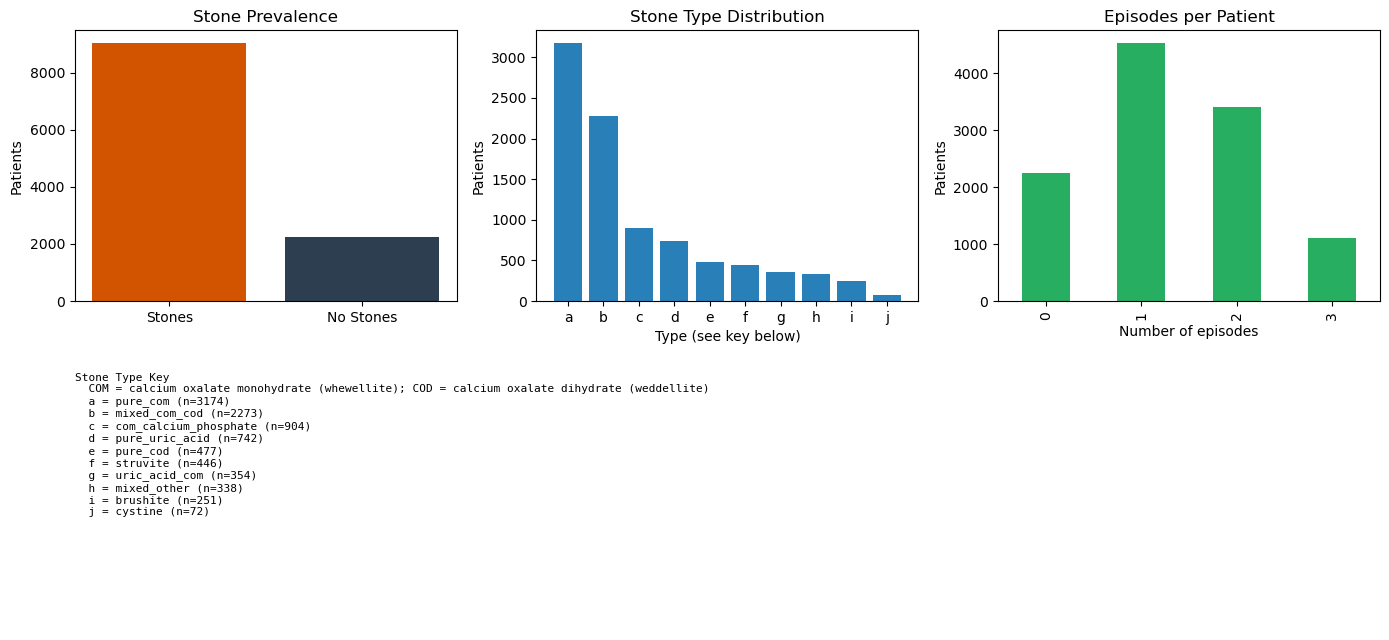


[Step 1 complete] Cohort summary saved to step1_cohort_summary.png


In [38]:
%run step1_cohort_summary.py

## Step 2: Stone Composition Profiling (PD1 - PXRD/FTIR)

Step 2: Parsing PD1 CIF files for composition data...
  Found 14,638 CIF files
  Parsed 14,638 specimens successfully
  Minerals detected: ['brushite', 'cystine', 'hydroxyapatite', 'struvite', 'uric_acid', 'weddellite', 'whewellite']

--- Mean Composition by Stone Type (%) ---
  pure_com (n=5123): whewellite=100.0%
  mixed_com_cod (n=3632): whewellite=74.9%, weddellite=25.1%
  com_calcium_phosphate (n=1475): whewellite=64.8%, hydroxyapatite=35.2%
  pure_uric_acid (n=1199): uric_acid=100.0%
  pure_cod (n=823): weddellite=100.0%
  struvite (n=717): struvite=84.7%, hydroxyapatite=15.3%
  uric_acid_com (n=575): uric_acid=55.0%, whewellite=45.0%
  mixed_other (n=554): uric_acid=21.7%, hydroxyapatite=20.2%, whewellite=19.7%, weddellite=19.5%, struvite=18.9%
  brushite (n=415): brushite=90.1%, hydroxyapatite=9.9%
  cystine (n=125): cystine=100.0%

--- Cross-Reference Verification ---
  patient_stones.csv episodes (non-none): 14,638
  CIF files parsed: 14,638
  ✓ Counts match — one CIF per sto

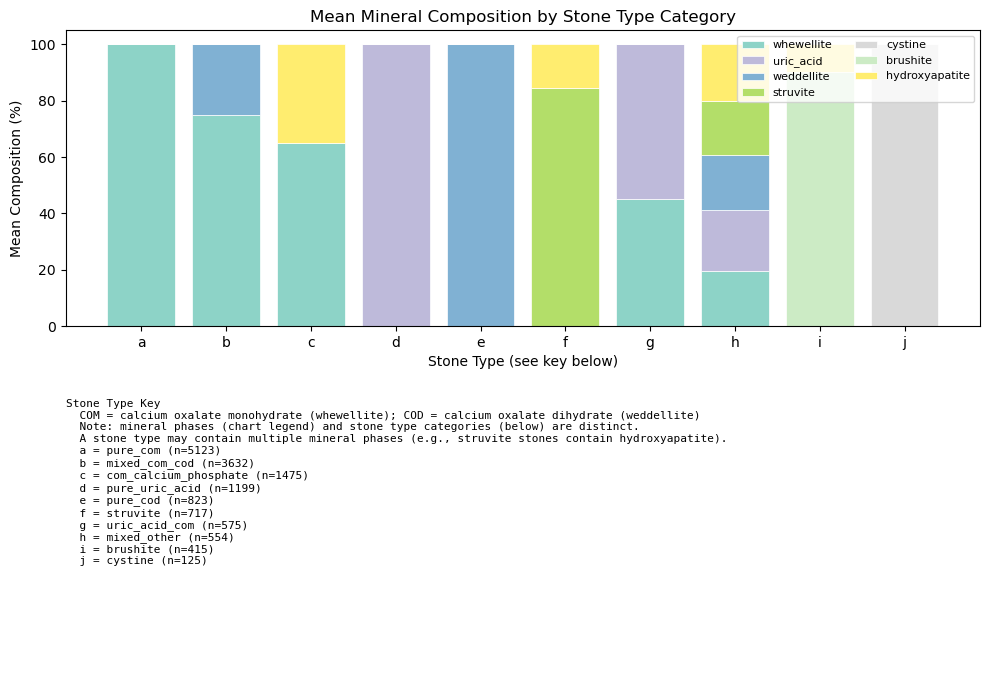


[Step 2 complete] Composition figure saved to step2_stone_composition.png


In [39]:
%run step2_stone_composition.py

## Step 3: Genomic Correlation (PD2 - VCF)

Step 3: Parsing PD2 VCF files for pathogenic variants...
  Found 11,272 VCF files
  Pathogenic variants found: 19,033
  Patients with pathogenic variants: 8,672
  Genes represented: ['AGXT', 'APRT', 'CASR', 'CLCN5', 'GRHPR', 'HOGA1', 'SLC22A12', 'SLC3A1', 'SLC7A9', 'VDR']

--- Merging with stone type assignments ---
  Pathogenic variants in non-stone patients: 0

--- Gene-Stone Type Concordance ---
  Concordant (gene predicts correct stone type): 5,542 (29.1%)
  Discordant: 13,491 (70.9%)
  Total pathogenic variants checked: 19,033

--- Gene Variant Frequency by Stone Type ---
  Generating heatmap figure...


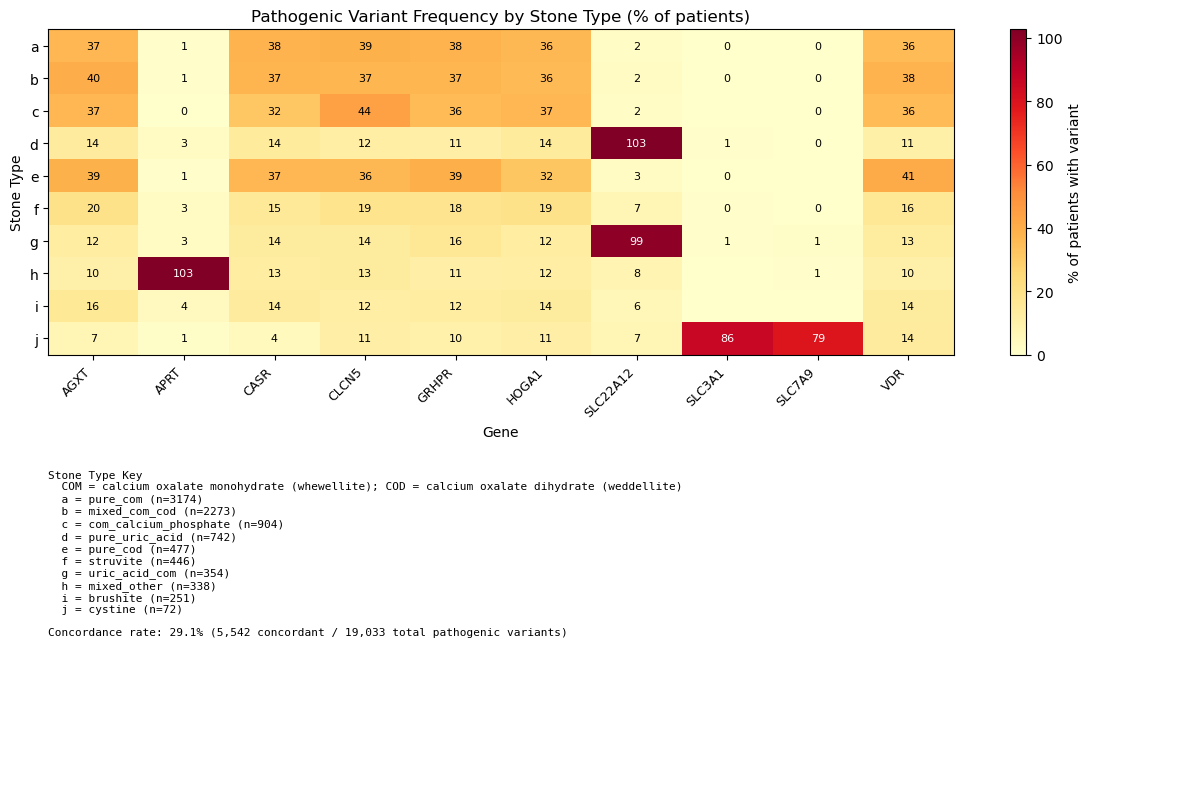


[Step 3 complete] Heatmap saved to step3_genomic_correlation.png


In [40]:
%run step3_genomic_correlation.py

## Step 4: Lab Value Trajectories (PD3)

Step 4: Analyzing PD3 lab value trajectories...
  Loading lab results (this may take a moment)...
  Lab results: 1,468,727 rows
  Panels: ['bmp', 'cbc', 'hba1c', 'lipid', 'liver', 'stone_panel']
  Patients: 11,272
  Visits per patient: {'mean': 7.469748048261178, 'min': 3.0, 'max': 12.0}

  Stone panel rows: 500,464
  Stone panel rows (stone patients only): 433,240

--- Mean Stone Panel Values by Stone Type ---

  urine_calcium:
    brushite: mean=277.6, std=74.8, n=1434
    com_calcium_phosphate: mean=309.2, std=78.6, n=5395
    cystine: mean=225.4, std=76.0, n=450
    mixed_com_cod: mean=288.7, std=77.3, n=13634
    mixed_other: mean=255.2, std=77.0, n=2016
    pure_cod: mean=278.7, std=75.0, n=2972
    pure_com: mean=298.7, std=77.6, n=19013
    pure_uric_acid: mean=217.3, std=71.2, n=4532
    struvite: mean=222.3, std=71.6, n=2589
    uric_acid_com: mean=261.3, std=74.1, n=2120

  urine_oxalate:
    brushite: mean=34.9, std=13.7, n=1434
    com_calcium_phosphate: mean=46.4, std=15.

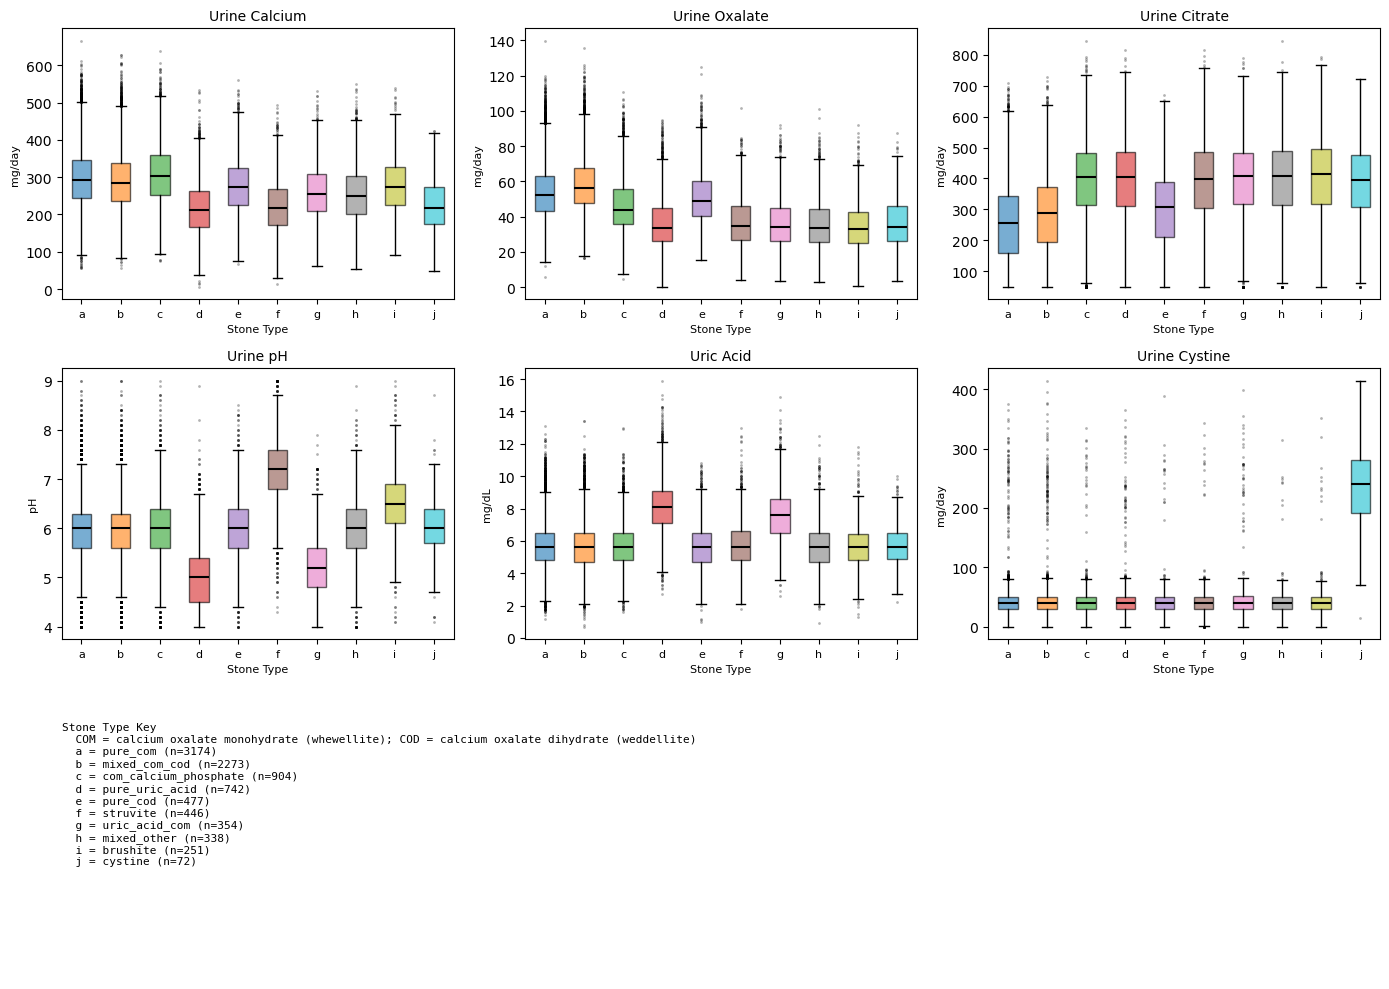

  Generating uric acid detail figure...


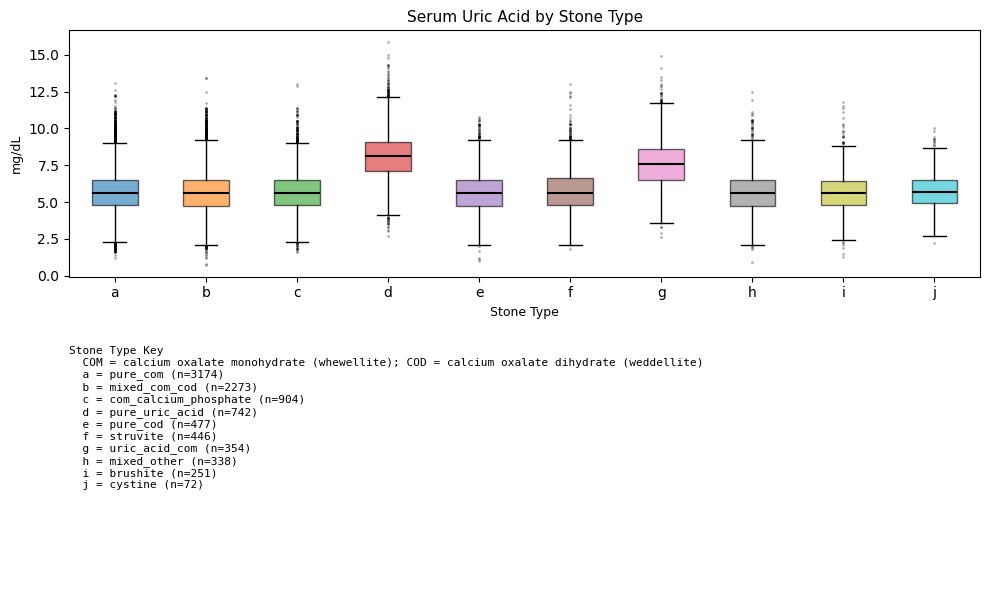


[Step 4 complete] Figures saved to step4_lab_trajectories.png and step4_uric_acid_detail.png


In [41]:
%run step4_lab_trajectories.py

## Step 5: Multi-Modal Integration

Step 5: Building multi-modal integrated patient view...
  Base cohort: 11,272 patients
  Extracting PD1 features (composition)...
    PD1 features for 9,031 patients
  Extracting PD2 features (genomics)...
    PD2 features for 11,272 patients
    Patients with pathogenic variants: 8,672
  Extracting PD3 features (mean lab values)...
    PD3 features for 11,196 patients

  Merging all modalities...
  Integrated DataFrame: 11,272 patients × 19 features
  Columns: ['mrn', 'person_id', 'has_stones', 'n_episodes', 'primary_stone_type', 'dominant_mineral', 'dominant_pct', 'n_minerals', 'pathogenic_variant_count', 'pathogenic_gene_count', 'has_pathogenic', 'lab_phosphorus', 'lab_pth', 'lab_uric_acid', 'lab_urine_calcium', 'lab_urine_citrate', 'lab_urine_cystine', 'lab_urine_oxalate', 'lab_urine_ph']

--- Data Completeness ---
  Patients with PD1 data (composition): 9,031
  Patients with PD2 data (genomics): 11,272
  Patients with PD3 data (labs): 11,196
  Stone patients with ALL modalities: 9

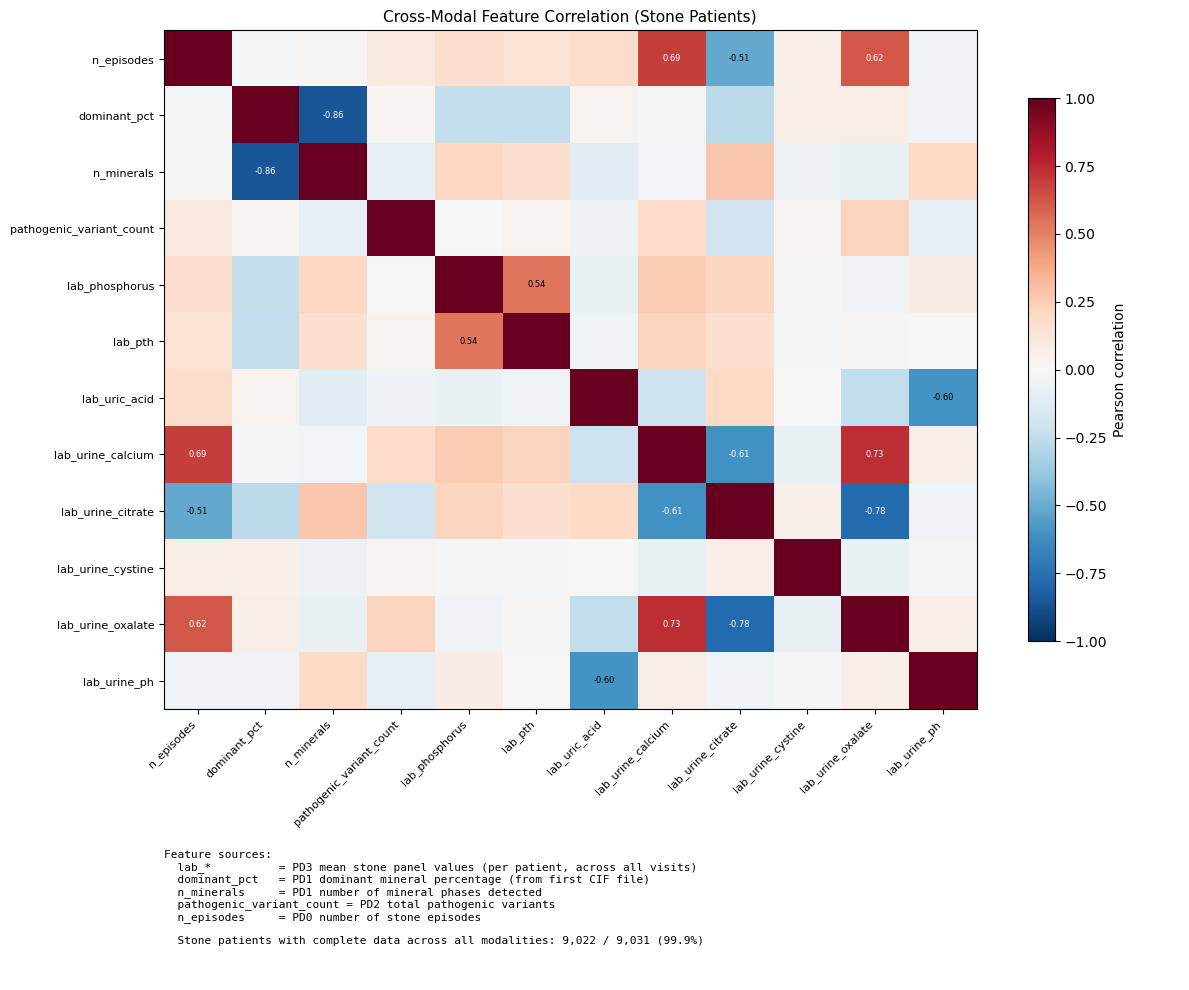


[Step 5 complete] Correlation heatmap saved to step5_multimodal_integration.png
  integrated_df available: 11,272 patients × 19 features


In [42]:
%run step5_multimodal_integration.py

## Step 6: Predictive Model

Step 6: Building predictive model (genomics + labs → stone type)...
  Loading PD2 genomic features...
    PD2: 11,272 patients, 10 gene features
  Loading PD3 lab features...
    PD3: 11,196 patients, 8 lab features
  Merging features...
  Model dataset: 9,022 patients × 18 features
  Stone types: 10

--- Training Random Forest Classifier ---
  5-fold CV accuracy: 63.5% ± 0.5%
  Overall accuracy: 63.5%

--- Classification Report ---
                       precision    recall  f1-score   support

             brushite       0.79      0.62      0.69       251
com_calcium_phosphate       0.67      0.83      0.74       903
              cystine       0.76      0.57      0.65        72
        mixed_com_cod       0.59      0.54      0.56      2271
          mixed_other       0.87      0.60      0.71       338
             pure_cod       0.57      0.13      0.21       477
             pure_com       0.60      0.72      0.65      3171
       pure_uric_acid       0.68      0.75      0.71      

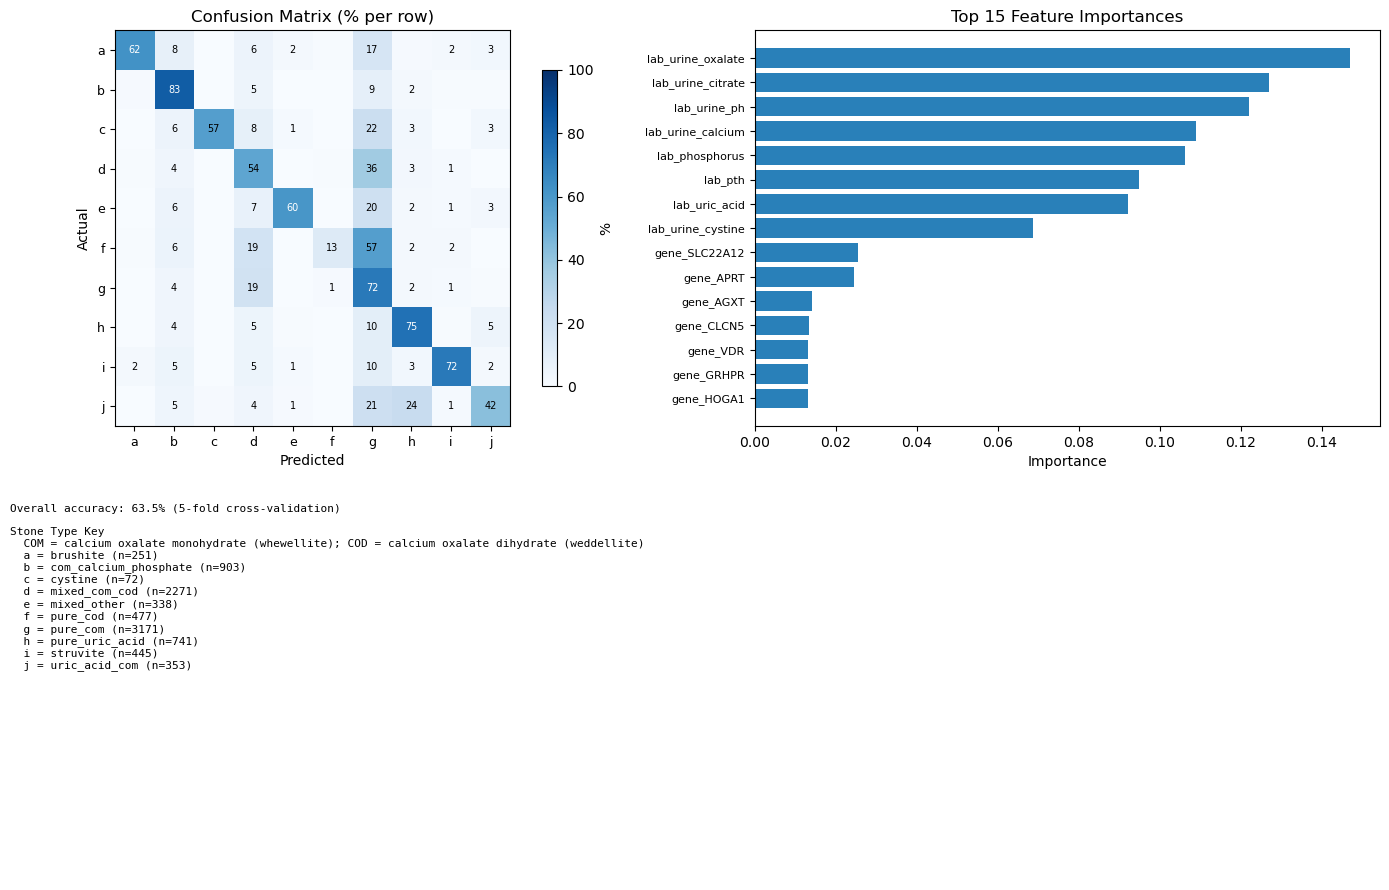


[Step 6 complete] Model evaluation figure saved to step6_predictive_model.png


In [43]:
%run step6_predictive_model.py